### Principle 

These are the exercises from the Bogarcz paper. In order. For specifics refer to the paper

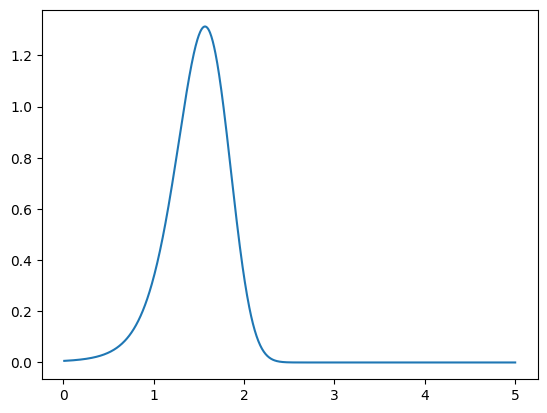

[1.56843844]


In [1]:
## Exercise 1

import numpy as np 

    ## Parameters

V = np.linspace(0.01,5,1000)

    # Prior 
Sp = 1
vp = 3

    #Likelihood
Su = 1
u = 2


def f(x,mu,S): #Normal PDF
    return np.exp(-((x-mu)**2)/(2*S))*1/(np.sqrt(2*np.pi*S))

## Calculate normalization term over V
num = f(V,vp,Sp)*f(u,V**2,Su)
k = (5-0.01)/V.shape[0] #interval between values
norm = np.sum(num*k) #Simulate integral with Riemann sum 

import matplotlib.pyplot as plt 

fig, ax = plt.subplots()

ax.plot(V,num/norm)

plt.show()
I = np.where(num/norm == np.max(num/norm))
print(V[I])

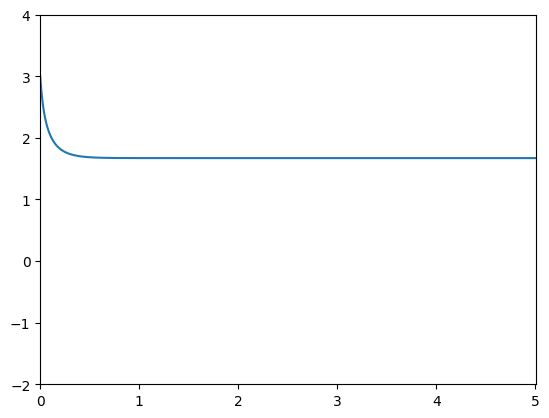

[1.6716998816571864, 1.6716998816571846, 1.6716998816571829, 1.6716998816571813, 1.6716998816571798, 1.6716998816571784, 1.671699881657177, 1.671699881657176, 1.6716998816571749, 1.6716998816571738, 1.6716998816571729, 1.671699881657172, 1.671699881657171, 1.6716998816571704, 1.6716998816571698, 1.671699881657169, 1.6716998816571684, 1.671699881657168, 1.6716998816571675, 1.671699881657167, 1.6716998816571667, 1.6716998816571662, 1.6716998816571658, 1.6716998816571653, 1.671699881657165, 1.6716998816571649, 1.6716998816571647, 1.6716998816571644, 1.6716998816571642, 1.671699881657164, 1.6716998816571638, 1.6716998816571635, 1.6716998816571633, 1.671699881657163, 1.6716998816571629, 1.6716998816571627, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998816571624, 1.6716998

In [2]:
## Exercise 2 Gradient ascent using Euler's method to update the value of prior value of the latent variable

T = [0] # number of time steps 
dt = 0.01
x = [vp]
phi = [vp]

def dFdPhi(phi,u=u,vp=vp,Sp=Sp,Su=Su): 
    return (vp-phi)/Sp + 2*phi*(u-phi**2)/(2*Su)



    #Eulers :

step = 0
def eulers(x,dx,step,dt=dt):
    x.append(x[step] + dt*dx(x[step]))
while T[-1] < 5 :
    
    eulers(phi,dFdPhi,step = step)
    # phi.append(phi[step] + dt*dFdPhi(phi[step]))  #Eulers method 
          
    T.append(T[-1]+dt)
    step += 1 

fig, ax = plt.subplots()

ax.plot(T,phi)
ax.set_ylim(-2,4)
ax.set_xmargin(0)

plt.show()
print(phi[-100:])


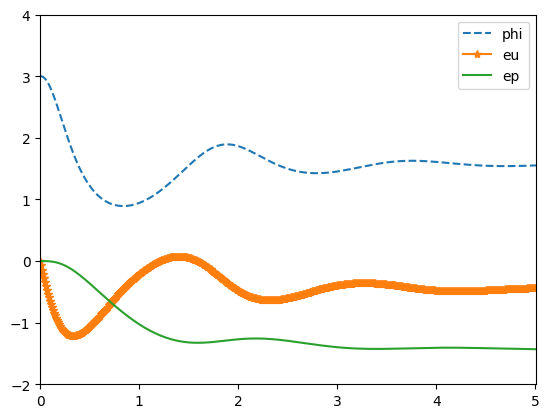

[1.6074002514623569, 1.6060309488693474, 1.6046401158616004, 1.6032299123883864, 1.6018024784307918, 1.6003599313571064, 1.5989043633938589, 1.5974378392139779, 1.595962393643135, 1.5944800294849286, 1.5929927154651797, 1.5915023842952523, 1.5900109308539565, 1.5885202104872767, 1.587032037424854, 1.5855481833118752, 1.584070375854751, 1.582600297578731, 1.5811395846953762, 1.5796898260776147, 1.578252562339923, 1.5768292850210202, 1.5754214358663163, 1.5740304062072443, 1.5726575364344928, 1.5713041155620808, 1.5699713808791425, 1.5686605176862392, 1.567372659112983, 1.566108886013728, 1.5648702269380828, 1.5636576581729977, 1.5624721038532, 1.5613144361367697, 1.5601854754426971, 1.5590859907472945, 1.5580166999363994, 1.5569782702103625, 1.5559713185388835, 1.5549964121628264, 1.554054069140232, 1.5531447589338214, 1.55226890303737, 1.551426875638427, 1.5506190043149384, 1.549845570763427, 1.5491068115564817, 1.5484029189273896, 1.5477340415798553, 1.5471002855208305, 1.546501714914

In [3]:
## Exercise 3 : 
    #Init
T = [0] 
phi = [vp]
ep = [0]
eu = [0]

def dEp(phi,ep,step,vp=vp,Sp=Sp):
    return phi[step] - vp - Sp*ep[step]
def dEu(phi,eu,step,u=u,Su=Su): 
    return u - phi[step]**2 - Su*eu[step]
def dFdPhi(phi,eu,ep,step): 
    return eu[step]*2*phi[step] - ep[step] 



    #Eulers :

step = 0
while T[-1] < 5 :
    
    phi.append(phi[step] + dt*dFdPhi(phi,eu,ep,step)) #update internal representation first according to errors.
    eu.append(eu[step] + dt*dEu(phi,eu,step))
    ep.append(ep[step] + dt*dEp(phi,ep,step))
    
    T.append(T[-1]+dt)
    step += 1 

fig, ax = plt.subplots()

ax.plot(T,phi,'--',label='phi')
ax.plot(T,eu,'-*',label='eu')
ax.plot(T,ep,label='ep')

ax.set_ylim(-2,4)
ax.set_xmargin(0)
ax.legend()

plt.show()
print(phi[-100:])





In [5]:
## Exercise 4 Math




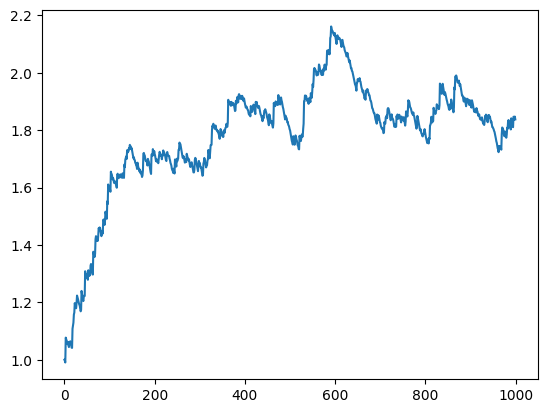

In [45]:
## Exercise 5 

Ntrial = 1000

#Model parameters
Si = [1] #values of signma for each trial
gi = 5 #g(phi i+1) output function of the above layer
    #derivative of inhib and prediction fr
    

def depsI(phi,gi,ei):
    return phi - gi -ei
def dei(Si,epsI,ei):
    return Si*epsI - ei
a = 0.01 #learning rate

# time 
dt = 0.01 #euler increment


for trial in range(Ntrial-1):
    epsI = 0 #prediction error firing rate in layer I 
    ei = 0 #inhib firing rate

    T = 0 #time series
    phi = np.random.normal(5,np.sqrt(2))
    while T < 20: #20 time steps 

        epsI += dt*depsI(phi,gi,ei)
        ei += dt*dei(Si[trial],epsI,ei)
        T += dt
    
    Si.append(Si[trial] + a*(epsI*ei-1))
        
        
fig, ax = plt.subplots()

ax.plot(np.arange(0,Ntrial),Si)
plt.show()
    

[1,
 0.9900695389351291,
 0.9800189723113923,
 0.970022688175097,
 0.9599133703241596,
 0.9500109305097246,
 0.9400846892995555,
 0.93006877127058,
 0.9201148783964387,
 0.9101993704663778,
 0.9002484603485812,
 0.8902603316343415,
 0.8803382224768433,
 0.8704050508500892,
 0.860363954990914,
 0.8504258751390847,
 0.8404359275623728,
 0.830644274605706,
 0.8207656871526485,
 0.8107697950781781,
 0.8007792521021948,
 0.79087053106606,
 0.7812196638663848,
 0.7712052811314974,
 0.7612194687178664,
 0.7512648341109367,
 0.7412930419319216,
 0.7313474183531604,
 0.721392774038491,
 0.7113999173176717,
 0.7014847130221799,
 0.6916485410262416,
 0.6820142833045895,
 0.6721271231677202,
 0.6621824021358427,
 0.6523228784310815,
 0.6424711631351812,
 0.6327079572127058,
 0.622690096642082,
 0.6128068030499564,
 0.60280157484077,
 0.5928890207386016,
 0.5828950935812638,
 0.5729480154321179,
 0.563006265853558,
 0.553008187352613,
 0.5430447015087141,
 0.5330373499360693,
 0.5230825731038428,
 